# HDiv-VIM backends showcase — hex RT1 (3D) and planar tri/quad (2D)

**Status snapshot (2026-07-03, radia 4.95.5).** This executed notebook demonstrates the HDiv-VIM
surface that shipped *after* the June-27 showcases
([`hdiv_curved_showcase.ipynb`](hdiv_curved_showcase.ipynb) — curved P2 tetrahedra;
[`polynomial_charge_field.ipynb`](polynomial_charge_field.ipynb) — RT1 polynomial charges):

1. **Pure-hex RT1 charge Gram** — Q1 volume charges (the "hex gotcha": `div(HDiv order-1)` on a hex is
   Q1, *not* P0) + quad-face surface charges, extracted **Piola-exactly** on the 27-node Q2 geometry.
   Built as a HACApK **H-matrix** with symmetric leaf fill and static-site radial inner quadrature
   (the 2026-07 build-speed work; ~10x on the cylinder benchmarks).
2. **2D planar tri/quad charge Gram** (motor cross-sections) — the log kernel `-ln r / 2pi`,
   charges = `-div M` on cells (P0 on tri, **Q1 on quad** — the 2D twin of the hex gotcha) + `M.n`
   on boundary edges, gated by closed forms (disk demag exactly 1/2, ellipse thirds,
   2D Clausius–Mossotti).
3. The production one-call **`radia.vim.Solve`** on a tet sphere (all-C++ symmetric
   mass-Riesz CG through the H-matrix).

Every gate below is also locked as a golden in `validation_test/feec/`
(`test_hdiv_vim_hex_rt1_wiring.py`, `test_hdiv_vim_2d_wiring.py`, `test_hdiv_vim_demag_solve.py`);
this notebook is the *rendered showcase layer* over that validation lane, per the
Validation-Class Examples Promotion Lane policy. The physical anchor throughout is the demag bound:
the generalized eigenvalues of `M_mass^-1 N` (with `N = B^T G B`) must lie in `[0, 1]`.

In [1]:
import json, platform, time
import numpy as np
import scipy.linalg as sla
import ngsolve as ng
from ngsolve.meshes import MakeStructured2DMesh, MakeStructured3DMesh
from netgen.occ import WorkPlane, OCCGeometry
from netgen.csg import CSGeometry, Sphere, Pnt
import radia
from radia.vim import ChargeGram
from radia.vim import Solve

RESULTS = {
    "radia_version": radia.__version__,
    "numpy_version": np.__version__,
    "platform": platform.platform(),
}
print("radia", radia.__version__, "| numpy", np.__version__, "|", platform.platform())


# Materialize N = B^T G B column-by-column through the symmetric H-matrix matvec.
def materialize_N(B, G):
    n = B.shape[1]
    N = np.zeros((n, n))
    e = np.zeros(n)
    for j in range(n):
        e[j] = 1.0
        N[:, j] = B.T @ np.asarray(G.matvec_sym((B @ e).tolist()), float)
        e[j] = 0.0
    return 0.5 * (N + N.T)


# Shared spectrum + axis-demag gate (call inside a TaskManager region).
def gate(fes):
    B, G, M_mass = ChargeGram(fes)
    N = materialize_N(B, G)
    Md = M_mass.toarray()
    w = sla.eigh(N, Md, eigvals_only=True)
    chk = G.hex_state_check()  # instance-integrity canary (fails loud on state corruption)
    assert chk["ctor"] == chk["now"], f"Gram state canary mismatch {chk}"
    dim = fes.mesh.dim
    D = []
    for k in range(dim):
        comp = [0.0] * dim
        comp[k] = 1.0
        gf = ng.GridFunction(fes)
        gf.Set(ng.CoefficientFunction(tuple(comp)))
        mu = gf.vec.FV().NumPy().copy()
        D.append(float(mu @ (N @ mu)) / float(mu @ (Md @ mu)))
    return w, D, N, Md

radia 4.95.5 | numpy 2.4.6 | Windows-2022Server-10.0.20348-SP0


## 1. Pure-hex RT1 — spectrum bound + cube demag factor

`ChargeGram(HDiv(hexmesh, order=1))` auto-routes a pure-hex mesh to the C++ hex charge Gram.
Gates on a structured 3x3x3 cube (affine and trilinearly distorted): the demag spectrum stays in
`[0, 1]` and the uniform-`M_z` Rayleigh quotient reproduces the cube demag factor `1/3`.

In [2]:
rows = []
for name, mapping in [
    ("affine", lambda x, y, z: (0.02 * x, 0.02 * y, 0.02 * z)),
    ("distorted", lambda x, y, z: (0.02 * (x + 0.15 * y * z),
                                   0.02 * (y + 0.10 * x * z),
                                   0.02 * (z + 0.12 * x * y))),
]:
    mesh = MakeStructured3DMesh(hexes=True, nx=3, ny=3, nz=3, mapping=mapping)
    with ng.TaskManager():
        fes = ng.HDiv(mesh, order=1)
        w, D, _, _ = gate(fes)
    assert w.min() > -1e-8, f"{name}: N not PSD"
    assert 0.99 < w.max() < 1.005, f"{name}: spectrum escaped [0,1]: {w.max():.6f}"
    assert 0.31 < D[2] < 0.35, f"{name}: cube demag {D[2]:.4f} off 1/3"
    rows.append({"mesh": name, "ndof": fes.ndof, "eig_min": float(w.min()),
                 "eig_max": float(w.max()), "D_z": D[2]})
    print(f"{name:10s} ndof={fes.ndof:5d}  eig(M^-1 N) in [{w.min():+.1e}, {w.max():.6f}]  "
          f"D_z={D[2]:.5f}  (cube exact: 1/3)")
RESULTS["hex_rt1_3x3x3"] = rows

affine     ndof=  756  eig(M^-1 N) in [-1.0e-15, 0.999017]  D_z=0.33271  (cube exact: 1/3)


distorted  ndof=  756  eig(M^-1 N) in [-8.8e-16, 0.997762]  D_z=0.33287  (cube exact: 1/3)


## 2. Genuine trilinear warp — the worst hex of a real Cubit cylinder mesh

Near-affine boxes cannot catch warped-hex regressions: the pre-Piola charge model passed them at
0.998 while **converging to eig 1.0105 > 1** on this real-mesh hex (`|J|min/max = 0.376`) — the
non-Coulomb-orthogonal L2 charge projection leaked the physical bound by `O(warp^2)`. The
Piola-exact charge extraction keeps the bound on genuine warp.

In [3]:
WORST_CYL_HEX_CORNERS = np.array([  # x-fastest corner order (ix + 2*iy + 4*iz)
    (-0.5, 1e-16, 0.5),
    (-0.4619397662556434, 0.1913417161825449, 0.5),
    (-0.3799374424886703, -5.15188134101e-05, 0.5),
    (-0.3135968748399616, 0.0996211631527812, 0.5),
    (-0.5, -1e-16, 0.3),
    (-0.461939766255643, 0.1913417161825455, 0.3),
    (-0.3799374424886702, -5.151881341e-05, 0.2999999999999999),
    (-0.3135968748399616, 0.0996211631527814, 0.2999999999999999),
])


def trilerp(x, y, z):
    out = np.zeros(3)
    for i in range(8):
        rx, ry, rz = i & 1, (i >> 1) & 1, (i >> 2) & 1
        out += ((x if rx else 1 - x) * (y if ry else 1 - y) * (z if rz else 1 - z)
                * WORST_CYL_HEX_CORNERS[i])
    return tuple(out)


mesh = MakeStructured3DMesh(hexes=True, nx=1, ny=1, nz=1, mapping=trilerp)
with ng.TaskManager():
    fes = ng.HDiv(mesh, order=1)
    w, D, _, _ = gate(fes)
assert w.min() > -1e-8 and w.max() < 1.005
print(f"warped real hex: eig(M^-1 N) in [{w.min():+.1e}, {w.max():.6f}]  "
      f"(pre-Piola model converged to 1.0105)")
RESULTS["hex_worst_warp"] = {"eig_min": float(w.min()), "eig_max": float(w.max())}

warped real hex: eig(M^-1 N) in [-3.6e-16, 0.838341]  (pre-Piola model converged to 1.0105)


## 3. H-matrix Gram build — timing snapshot

Fresh wall-clock measurement of the HACApK hex charge-Gram build on this machine (symmetric leaf
fill + static-site radial inner quadrature + block memo). The committed sidecar JSON records these
numbers; the full before/after history of the 2026-07 speed work (~10x day total on the cylinder
benchmarks, incl. curved) lives in the `hdiv-tet-hex-coupling-pyramid-gated` memory and the
`bench_hdiv_hex_vs_mmmm` probe.

n=2:    8 hexes,    160 charges  ->  H-matrix Gram build    1.129 s


n=4:   64 hexes,    896 charges  ->  H-matrix Gram build    6.002 s


n=6:  216 hexes,   2592 charges  ->  H-matrix Gram build   20.773 s


n=8:  512 hexes,   5632 charges  ->  H-matrix Gram build   57.021 s


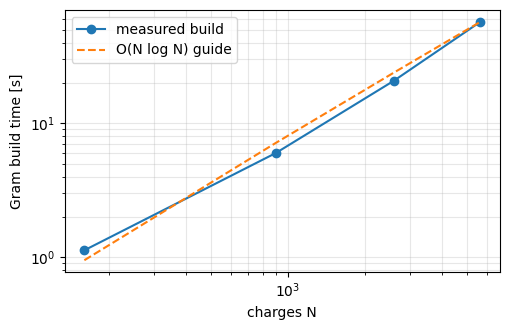

In [4]:
import matplotlib.pyplot as plt

scal = []
for n in (2, 4, 6, 8):
    mesh = MakeStructured3DMesh(hexes=True, nx=n, ny=n, nz=n,
                                mapping=lambda x, y, z: (0.02 * x, 0.02 * y, 0.02 * z))
    with ng.TaskManager():
        fes = ng.HDiv(mesh, order=1)
        t0 = time.perf_counter()
        B, G, M_mass = ChargeGram(fes)
        dt = time.perf_counter() - t0
    nq = int(G.ndof())
    scal.append({"n": n, "hexes": n ** 3, "charges": nq, "build_s": round(dt, 3)})
    print(f"n={n}: {n**3:4d} hexes, {nq:6d} charges  ->  H-matrix Gram build {dt:8.3f} s")
RESULTS["hex_gram_build_scaling"] = scal

fig, ax = plt.subplots(figsize=(5.2, 3.4))
q = [s["charges"] for s in scal]
t = [s["build_s"] for s in scal]
ax.loglog(q, t, "o-", label="measured build")
ref = [t[-1] * (x / q[-1]) * np.log(x) / np.log(q[-1]) for x in q]
ax.loglog(q, ref, "--", label="O(N log N) guide")
ax.set_xlabel("charges N")
ax.set_ylabel("Gram build time [s]")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
fig.tight_layout()
display(fig)
plt.close(fig)

## 4. 2D planar tri/quad — closed-form gates (motor cross-section layer)

The 2D Gram uses the log kernel `-ln r / 2pi`; the arbitrary `ln`-scale shift is killed because
every HDiv dof column has zero total charge (divergence theorem). Gates:

* **disk** — transverse demag factor exactly `1/2`, and the linear solve reproduces the 2D
  Clausius–Mossotti relation `M/H0 = chi / (1 + chi/2)`;
* **ellipse 2:1** — `N_x = b/(a+b) = 1/3`, `N_y = 2/3`;
* **distorted quad square** — spectrum bound on a non-affine quad mesh (the outer quadrature must be
  product-Gauss: Dunavant-7's coherent misintegration of the potential's C1 kinks leaked the quad
  spectrum to 1.072 during bring-up while every entry agreed to ~3e-5).

In [5]:
# disk: demag 1/2 exact + Clausius-Mossotti solve
wp = WorkPlane().Circle(0, 0, 1.0).Face()
mesh = ng.Mesh(OCCGeometry(wp, dim=2).GenerateMesh(maxh=0.3))
with ng.TaskManager():
    fes = ng.HDiv(mesh, order=1)
    w, D, N, Md = gate(fes)
    gf = ng.GridFunction(fes)
    gf.Set(ng.CoefficientFunction((1.0, 0.0)))
    mux = gf.vec.FV().NumPy().copy()
assert w.max() < 1.005 and abs(D[0] - 0.5) < 2e-3 and abs(D[1] - 0.5) < 2e-3
print(f"disk   : ndof={fes.ndof:4d}  eig_max={w.max():.6f}  D=({D[0]:.5f}, {D[1]:.5f})  exact 1/2")
cm = []
for chi in (10.0, 999.0):
    A = Md / chi + N
    m = np.linalg.solve(A, Md @ mux)
    Mavg = float(mux @ (Md @ m)) / float(mux @ (Md @ mux))
    ref = chi / (1.0 + chi / 2.0)
    rel = abs(Mavg - ref) / ref
    assert rel < 3e-3
    cm.append({"chi": chi, "M_over_H0": Mavg, "cm2d_exact": ref, "rel_err": rel})
    print(f"         chi={chi:6.0f}: M/H0 = {Mavg:.6f}  vs 2D Clausius-Mossotti {ref:.6f}  (rel {rel:.1e})")
RESULTS["disk_2d"] = {"ndof": fes.ndof, "eig_max": float(w.max()), "D": D, "clausius_mossotti": cm}

# ellipse 2:1 -> thirds
wp = WorkPlane().Ellipse(2.0, 1.0).Face()
mesh = ng.Mesh(OCCGeometry(wp, dim=2).GenerateMesh(maxh=0.35))
with ng.TaskManager():
    fes = ng.HDiv(mesh, order=1)
    w, D, _, _ = gate(fes)
assert w.max() < 1.005 and abs(D[0] - 1 / 3) < 5e-3 and abs(D[1] - 2 / 3) < 5e-3
print(f"ellipse: ndof={fes.ndof:4d}  eig_max={w.max():.6f}  D=({D[0]:.5f}, {D[1]:.5f})  exact (1/3, 2/3)")
RESULTS["ellipse_2d"] = {"ndof": fes.ndof, "eig_max": float(w.max()), "D": D}

# distorted quad square: spectrum bound + Dx + Dy = 1 by symmetry
mesh = MakeStructured2DMesh(quads=True, nx=3, ny=3,
                            mapping=lambda x, y: (x + 0.15 * x * y * (1 - x),
                                                  y + 0.12 * x * y * (1 - y)))
with ng.TaskManager():
    fes = ng.HDiv(mesh, order=1)
    w, D, _, _ = gate(fes)
assert w.min() > -1e-8 and 0.99 < w.max() < 1.005
assert abs(D[0] - 0.5) < 5e-3 and abs(D[1] - 0.5) < 5e-3
print(f"dist-quad square: ndof={fes.ndof:4d}  eig in [{w.min():+.1e}, {w.max():.6f}]  "
      f"D=({D[0]:.5f}, {D[1]:.5f})")
RESULTS["distorted_quad_2d"] = {"ndof": fes.ndof, "eig_min": float(w.min()),
                                "eig_max": float(w.max()), "D": D}

disk   : ndof= 216  eig_max=0.999965  D=(0.50000, 0.50000)  exact 1/2
         chi=    10: M/H0 = 1.666949  vs 2D Clausius-Mossotti 1.666667  (rel 1.7e-04)
         chi=   999: M/H0 = 1.996604  vs 2D Clausius-Mossotti 1.996004  (rel 3.0e-04)
ellipse: ndof= 334  eig_max=0.999966  D=(0.33438, 0.66562)  exact (1/3, 2/3)


dist-quad square: ndof=  84  eig in [-5.7e-16, 0.999284]  D=(0.50001, 0.50001)


## 5. Production one-call — `Solve` on a tet sphere

The consolidated soft-iron entry point: linear `mu_r` (or a BH table / per-region dict / PM mix),
all-C++ symmetric mass-Riesz CG through the HACApK charge Gram. On the uniform-field sphere the
volume-average magnetization must match the analytic `M = chi / (1 + chi D) H0` with `D = 1/3`.

In [6]:
g = CSGeometry()
g.Add(Sphere(Pnt(0, 0, 0), 1.0))
with ng.TaskManager():
    mesh = ng.Mesh(g.GenerateMesh(maxh=0.45))
H0 = 1000.0  # A/m, +z
mu_r = 1000.0
with ng.TaskManager():
    res = Solve(mesh, mu_r, ng.CoefficientFunction((0, 0, H0)))
chi = mu_r - 1.0
D = res["demag"]
Mz = res["M_avg"][2]
M_selfD = chi / (1.0 + chi * D) * H0
M_exact = chi / (1.0 + chi / 3.0) * H0
print(f"sphere mu_r={mu_r:.0f}: n_el={res['n_el']}  linear_solver={res['linear_solver']}")
print(f"  demag D  = {D:.5f}  (exact 1/3)")
print(f"  Mz_avg   = {Mz:.2f} A/m ; chi/(1+chi*D)*H0 = {M_selfD:.2f} ; chi/(1+chi/3)*H0 = {M_exact:.2f}")
assert abs(D - 1 / 3) < 5e-3
assert abs(Mz - M_selfD) / M_selfD < 2e-3
RESULTS["tet_one_call_sphere"] = {"n_el": int(res["n_el"]), "demag": float(D),
                                  "Mz_avg": float(Mz),
                                  "linear_solver": str(res["linear_solver"])}

sphere mu_r=1000: n_el=158  linear_solver=mass-riesz-cg
  demag D  = 0.33347  (exact 1/3)
  Mz_avg   = 2993.70 A/m ; chi/(1+chi*D)*H0 = 2989.79 ; chi/(1+chi/3)*H0 = 2991.02


## 6. Honest status (2026-07-03) — shipped vs open

**Shipped, golden-locked** (`validation_test/feec/`, 44+ HDiv goldens):

* 3D **tet RT1** (flat + curved P2) — the primary loop-free soft-iron demag route; nonlinear
  energy-Newton all-C++ (deep-saturation robust); PM/per-region mixing; holed bodies.
* 3D **hex RT1** (flat + curved Q2 geometry) — Piola-exact charges; H-matrix build with symmetric
  fill + static-site radial inner quadrature (~10x vs the bring-up build); curved cylinder
  magnetic-moment error 0.13% via volume capture; the ~20k-charge use-after-free crash is fixed
  (cache-capacity clear on a reference-handing cache; commit 20e6e9e2).
* **2D planar tri/quad** — log-kernel Gram, closed-form gated (this notebook / commit a9999dd7).

**Open items** (tracked in memory `hdiv-tet-hex-coupling-pyramid-gated` / `hdiv-vim-tri-quad-motor`):

* curved-hex **cylinder eigenvalue 1.0078** (slightly above the [0,1] bound; halved from 1.0166 by
  the site anchors — remaining self/touching curved quadrature refinement);
* **wedge** elements (extruded motor stacks); **nonlinear hex** plumbing (solver must accept an
  external (B, G, M) triple); **2D nonlinear** iron;
* hex auto-dispatch policy (when a hex mesh should default to HDiv-VIM vs collocation MMMM);
* VIM <-> reduced-FEM weak-coupling (2D skeleton verified in research: stagger converges in 3
  iterations, plate loss within 7.8% of an all-in-one FEM reference — not yet promoted);
* the Sauter-Schwab 6D inner quadrature remains a **negative result** so far (prototype plateaus
  at 2e-3; needs a rigorous per-shuffle CPS second transform).

The role split stands: **HDiv-VIM = primary accurate route** (loop-free by construction,
mesh/mu_r-independent Newton); **collocation MMMM = transition / ELF-side cross-check** (hex/mesh-less, loop-polluted
internal M acceptable). See `docs/hdiv_vim/README.md` and the `hdiv_vim` MCP topic.

In [7]:
print(json.dumps(RESULTS, indent=1))

{
 "radia_version": "4.95.5",
 "numpy_version": "2.4.6",
 "platform": "Windows-2022Server-10.0.20348-SP0",
 "hex_rt1_3x3x3": [
  {
   "mesh": "affine",
   "ndof": 756,
   "eig_min": -1.0457544424431133e-15,
   "eig_max": 0.9990166926461084,
   "D_z": 0.33271288675921823
  },
  {
   "mesh": "distorted",
   "ndof": 756,
   "eig_min": -8.811778183262682e-16,
   "eig_max": 0.9977619888042581,
   "D_z": 0.3328748184465225
  }
 ],
 "hex_worst_warp": {
  "eig_min": -3.648720104587529e-16,
  "eig_max": 0.8383411143596173
 },
 "hex_gram_build_scaling": [
  {
   "n": 2,
   "hexes": 8,
   "charges": 160,
   "build_s": 1.129
  },
  {
   "n": 4,
   "hexes": 64,
   "charges": 896,
   "build_s": 6.002
  },
  {
   "n": 6,
   "hexes": 216,
   "charges": 2592,
   "build_s": 20.773
  },
  {
   "n": 8,
   "hexes": 512,
   "charges": 5632,
   "build_s": 57.021
  }
 ],
 "disk_2d": {
  "ndof": 216,
  "eig_max": 0.9999645769597206,
  "D": [
   0.5000020481402715,
   0.5000020997947036
  ],
  "clausius_mossott